# Road Quality Analysis (2020 Q1–Q4)

This notebook loads the 2020 quarterly Sentinel‑2 road statistics and derives
simple quality proxies:
- **Stability** (variability across quarters)
- **Moisture risk** (NDMI)
- **Bare soil exposure** (BSI + low NDVI)

We use Parquet for faster loading after the first run.


## Data set up

In [60]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/Users/miranda/Documents/GitHub/Sentinel-FYP/data")  # change if needed
df_2020 = pd.read_parquet(DATA_DIR / "ghana_parquet", filters=[("year","==",2020)])
df_all=df_2020.copy()  # placeholder for all years if needed
df_all.head()

,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI,year
0,520162721,trunk,Q1,0.157278,-0.142099,0.142099,-0.269918,0.183079,2020
1,574240962,trunk,Q1,0.089044,-0.130132,0.130132,-0.173877,0.156009,2020
2,574240965,trunk,Q1,0.058767,-0.161057,0.161057,-0.144965,0.174362,2020
3,574240966,trunk,Q1,0.053484,-0.161021,0.161021,-0.149151,0.175833,2020
4,574240968,trunk,Q1,0.090370,-0.135617,0.135617,-0.168844,0.155728,2020


In [ ]:
# Cell 6 — Per-road stats across quarters
road_stats = df_all.groupby(["osm_id", "fclass"]).agg(
    NDVI_mean=("NDVI", "mean"),
    NDVI_std=("NDVI", "std"),
    NDMI_mean=("NDMI", "mean"),
    NDMI_std=("NDMI", "std"),
    BSI_mean=("BSI", "mean"),
    BSI_std=("BSI", "std"),
    NDBI_mean=("NDBI", "mean"),
    NDWI_mean=("NDWI", "mean"),
).reset_index()

road_stats.head()


(329104, 10)

## Statistics 

In [54]:
# basic stats per class
basic_stats = road_stats.groupby("fclass").agg(
    count=("osm_id", "size"),
    NDVI_mean=("NDVI_mean", "mean"),
    NDVI_median=("NDVI_mean", "median"),
    NDMI_mean=("NDMI_mean", "mean"),
    NDMI_median=("NDMI_mean", "median"),
    BSI_mean=("BSI_mean", "mean"),
    BSI_median=("BSI_mean", "median"),
).sort_values("count", ascending=False)

basic_stats



,count,NDVI_mean,NDVI_median,NDMI_mean,NDMI_median,BSI_mean,BSI_median
fclass,,,,,,,
residential,258612,0.260491,0.249962,-0.084136,-0.093520,0.117834,0.126332
service,36318,0.185135,0.151797,-0.099379,-0.109227,0.122350,0.129323
unclassified,23166,0.374254,0.361181,-0.019301,-0.039222,0.060178,0.079239
tertiary,4929,0.237412,0.197219,-0.071595,-0.100709,0.103552,0.127440
secondary,2516,0.205340,0.166092,-0.078267,-0.100962,0.104815,0.118774
trunk,1887,0.191484,0.167418,-0.074839,-0.090321,0.103339,0.115407
primary,1676,0.200724,0.165710,-0.080756,-0.100682,0.108321,0.123868


In [ ]:
# seasonal variability (std across quarters) by class
var_stats = road_stats.groupby("fclass").agg(
    NDVI_std_mean=("NDVI_std", "mean"),
    NDMI_std_mean=("NDMI_std", "mean"),
    BSI_std_mean=("BSI_std", "mean")
).sort_values("NDVI_std_mean", ascending=False)

var_stats



,NDVI_std_mean,NDMI_std_mean,BSI_std_mean
fclass,,,
unclassified,0.102931,0.072006,0.070622
residential,0.069692,0.055005,0.055146
tertiary,0.057077,0.046648,0.047791
trunk,0.050064,0.047670,0.046653
secondary,0.050019,0.043995,0.044014
service,0.049703,0.043881,0.045528
primary,0.047532,0.042762,0.041394


In [ ]:
# correlation between indices (overall)
corr = road_stats[["NDVI_mean","NDMI_mean","BSI_mean","NDBI_mean","NDWI_mean"]].corr()
corr


,NDVI_mean,NDMI_mean,BSI_mean,NDBI_mean,NDWI_mean
NDVI_mean,1.000000,0.826239,-0.752035,-0.826239,-0.948216
NDMI_mean,0.826239,1.000000,-0.965276,-1.000000,-0.674179
BSI_mean,-0.752035,-0.965276,1.000000,0.965276,0.536748
NDBI_mean,-0.826239,-1.000000,0.965276,1.000000,0.674179
NDWI_mean,-0.948216,-0.674179,0.536748,0.674179,1.000000


### Interpretation of the correlation matrix

This table shows **Pearson correlations** between the mean spectral indices across all sampled roads.  
Values close to **+1** mean two indices increase together, values close to **−1** mean they move in opposite directions, and values near **0** mean little linear relationship.

**Key takeaways from the matrix:**
- **NDVI and NDMI are strongly positive** (e.g., ~0.84): greener vegetation tends to be wetter.
- **NDVI/NDMI are strongly negative with NDBI and BSI** (e.g., −0.77 to −1.00): vegetated/wet areas contrast with built‑up or bare soil.
- **NDBI and BSI are strongly positive** (e.g., ~0.97): built‑up and bare soil signals are closely related.
- **NDWI is strongly negative with NDVI** (e.g., −0.95): water signal tends to be higher where vegetation greenness is lower.

**What this means for analysis:**  
Several indices are **highly redundant** (strong correlations). For modeling or comparisons, you can keep a smaller subset (e.g., NDVI + NDBI + NDWI) without losing much information.


# Base‑level exploration (continuation)

This section adds:
1) Descriptive stats by class  
2) Distribution plots  
3) Seasonality (quarterly patterns)  
4) Region comparisons (if region exists)  
5) Urban vs rural proxy (NDVI/NDBI thresholds)


In [38]:
index_means = ["NDVI_mean","NDMI_mean","NDBI_mean","NDWI_mean","BSI_mean"]

desc_stats = (
    road_stats.groupby("fclass")[index_means]
    .agg(["mean","median","std","min","max","count"])
)

#desc_stats

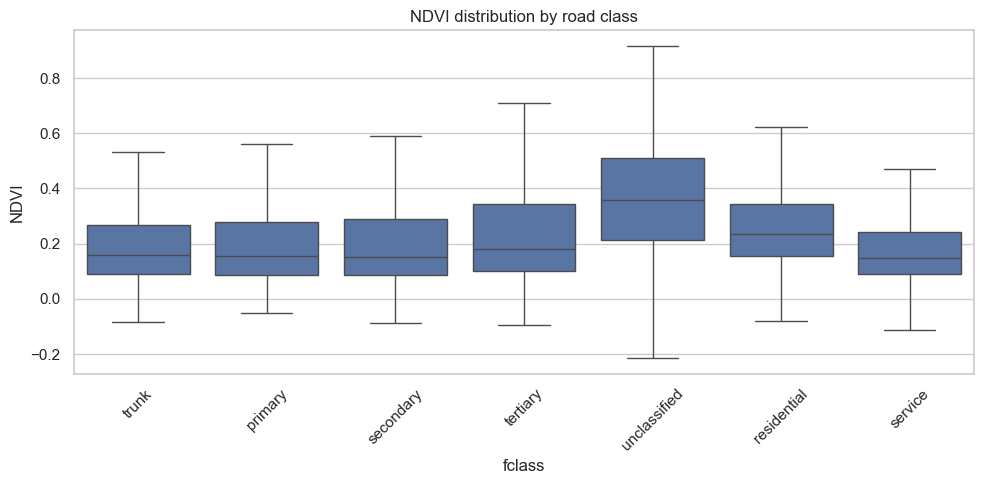

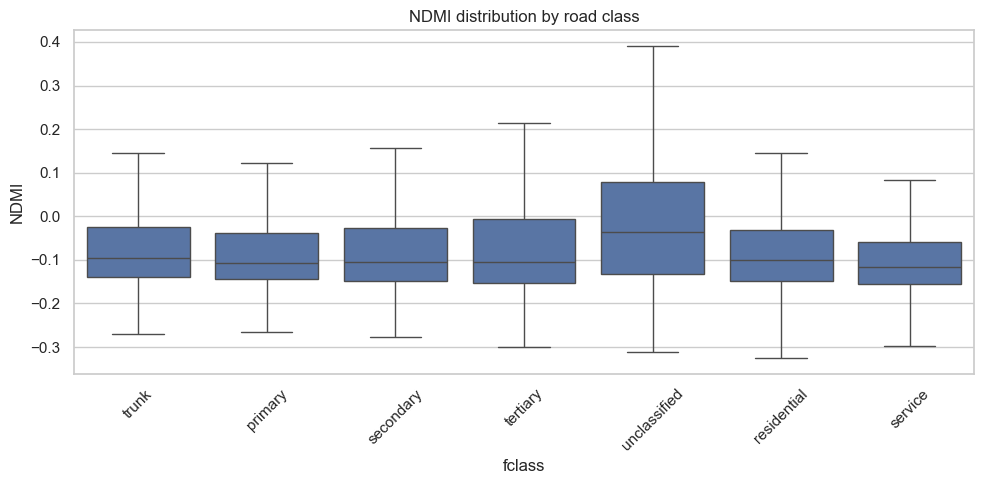

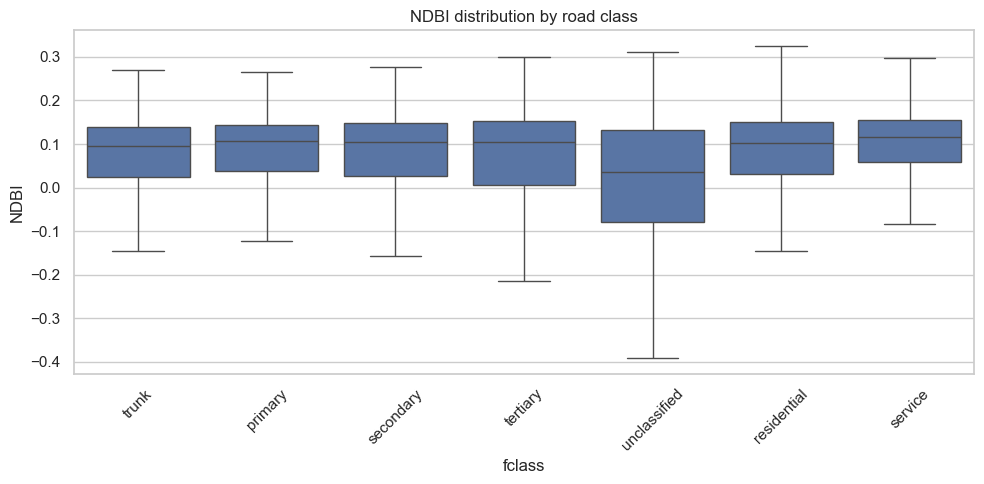

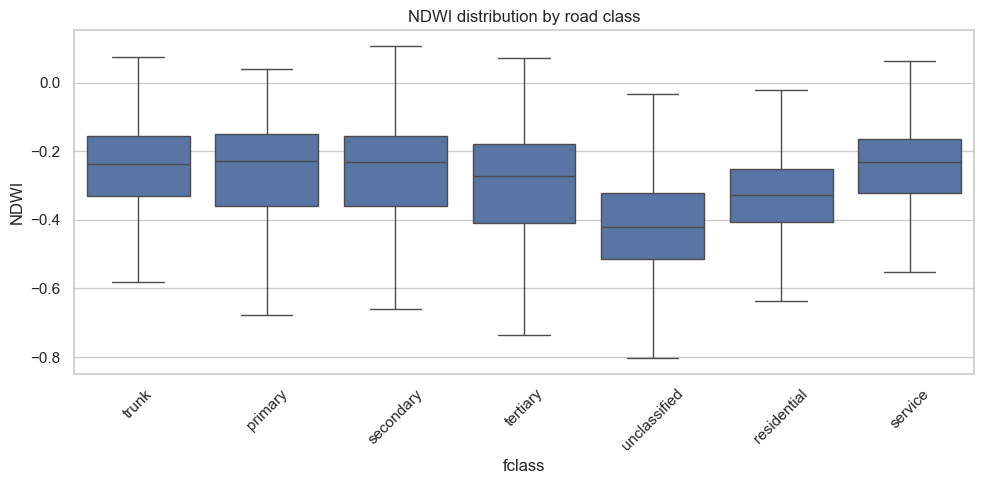

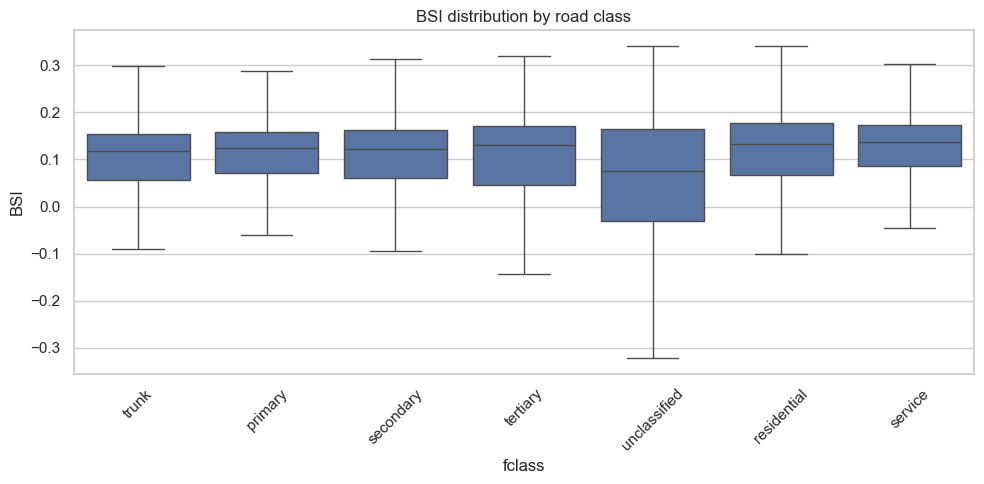

In [39]:
#  Distribution plots (boxplots) per class
# uses df_all (quarterly rows) so distribution is richer
import seaborn as sns
sns.set(style="whitegrid")

for col in ["NDVI","NDMI","NDBI","NDWI","BSI"]:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_all, x="fclass", y=col, showfliers=False)
    plt.title(f"{col} distribution by road class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

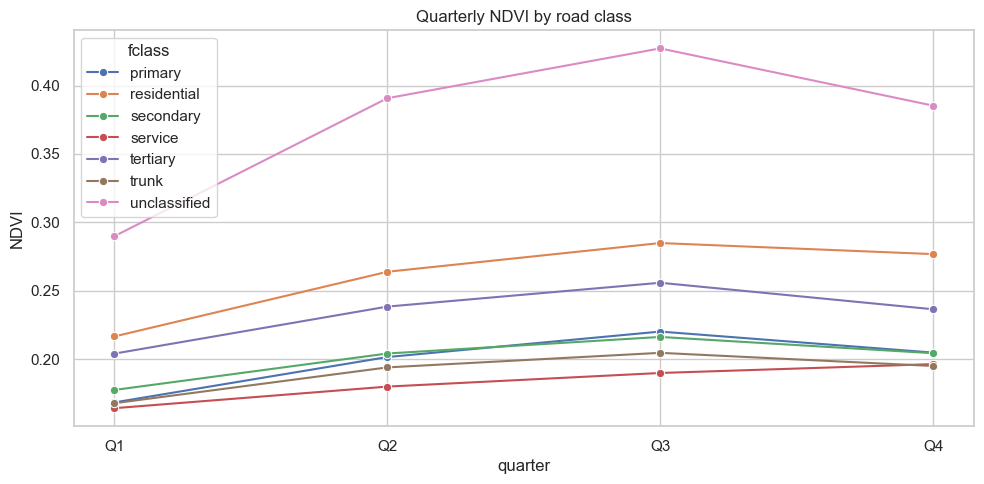

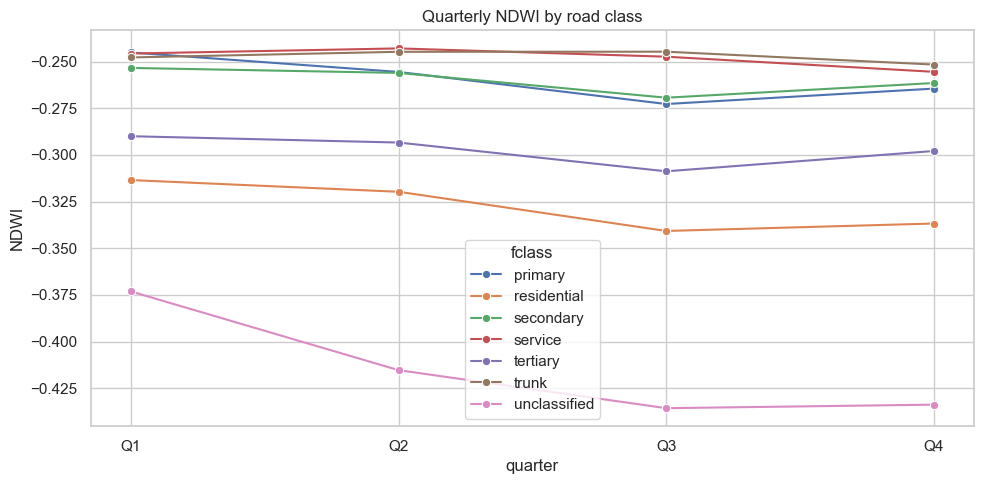

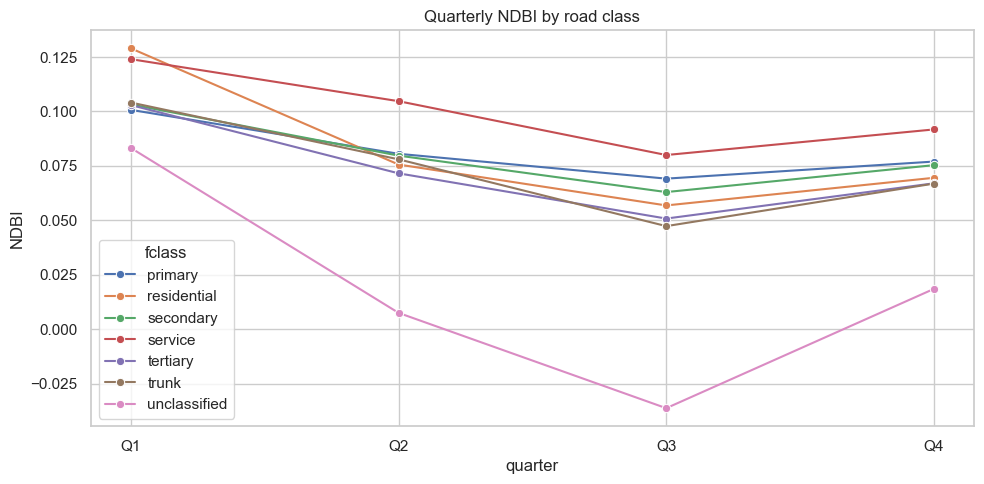

In [46]:
# Seasonality (quarterly patterns)
# average indices per class per quarter (from df_all)
q_stats = (
    df_all.groupby(["fclass","quarter"])[["NDVI","NDMI","NDBI","NDWI","BSI"]]
    .mean()
    .reset_index()
)

#  plot for NDVI
plt.figure(figsize=(10,5))
sns.lineplot(data=q_stats, x="quarter", y="NDVI", hue="fclass", marker="o")
plt.title("Quarterly NDVI by road class")
plt.tight_layout()
plt.show()

#  plot for NDWI
plt.figure(figsize=(10,5))
sns.lineplot(data=q_stats, x="quarter", y="NDWI", hue="fclass", marker="o")
plt.title("Quarterly NDWI by road class")
plt.tight_layout()
plt.show()

#  plot for NDBI
plt.figure(figsize=(10,5))
sns.lineplot(data=q_stats, x="quarter", y="NDBI", hue="fclass", marker="o")
plt.title("Quarterly NDBI by road class")
plt.tight_layout()
plt.show()

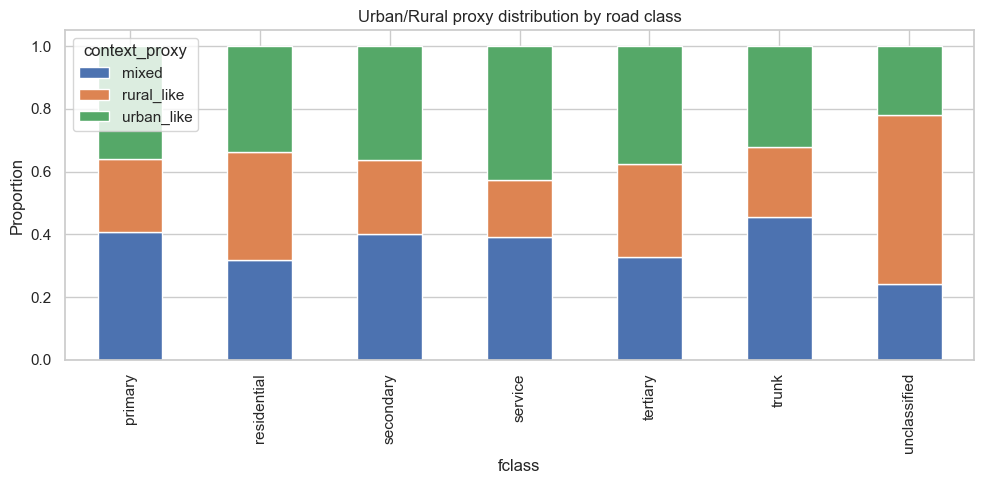

In [47]:
# Urban/rural proxy (NDVI + NDBI thresholds)
# Use overall distribution in df_all
ndbi_thr = df_all["NDBI"].quantile(0.6)
ndvi_thr = df_all["NDVI"].quantile(0.6)

def urban_rural(row):
    if row["NDBI"] >= ndbi_thr and row["NDVI"] <= ndvi_thr:
        return "urban_like"
    elif row["NDVI"] >= ndvi_thr and row["NDBI"] <= ndbi_thr:
        return "rural_like"
    else:
        return "mixed"

df_all["context_proxy"] = df_all.apply(urban_rural, axis=1)

proxy_counts = pd.crosstab(df_all["fclass"], df_all["context_proxy"], normalize="index")
proxy_counts

# Plot proxy proportions
proxy_counts.plot(kind="bar", stacked=True, figsize=(10,5))
plt.ylabel("Proportion")
plt.title("Urban/Rural proxy distribution by road class")
plt.tight_layout()
plt.show()



Further analysis:

6) Outlier analysis (extreme surfaces) - Identify roads with unusually high **BSI** or **NDBI** (possible bare soil or built‑up surfaces).

7) Correlation by class - Correlation matrices **within each road class** to see if relationships differ by type.

8) Feature importance (simple proxy) - Lightweight model to separate **unclassified vs others** just to see which indices matter.

9) Data quality checks - Missing value rates per index, overall and by class.



In [49]:
bsi_thr = road_stats["BSI_mean"].quantile(0.99)
ndbi_thr = road_stats["NDBI_mean"].quantile(0.99)

outliers = road_stats[
    (road_stats["BSI_mean"] >= bsi_thr) | (road_stats["NDBI_mean"] >= ndbi_thr)
].sort_values(["BSI_mean","NDBI_mean"], ascending=False)

print("Outliers (top 1%):", len(outliers))
outliers.head(20)

Outliers (top 1%): 5266


,osm_id,fclass,NDVI_mean,NDVI_std,NDMI_mean,NDMI_std,BSI_mean,BSI_std,NDBI_mean,NDWI_mean
280609,1190944650,residential,0.068986,0.015245,-0.290880,0.026158,0.320449,0.035939,0.290880,-0.292455
280610,1190944651,residential,0.077929,0.016467,-0.279715,0.017005,0.307970,0.024612,0.279715,-0.293383
299691,1312200249,residential,0.119618,0.067048,-0.262233,0.034887,0.305341,0.035602,0.262233,-0.331690
283819,1218403529,residential,0.103450,0.026910,-0.286887,0.035346,0.305301,0.029249,0.286887,-0.300913
283696,1217885548,unclassified,0.153712,0.074700,-0.257499,0.040365,0.302777,0.037313,0.257499,-0.358043
192524,634983837,residential,0.147420,0.007592,-0.238649,0.010959,0.298507,0.010479,0.238649,-0.391563
56885,491004753,tertiary,0.123514,0.005857,-0.222429,0.023968,0.297860,0.023616,0.222429,-0.402862
279505,1181818842,unclassified,0.119310,0.031923,-0.231526,0.041670,0.295684,0.038534,0.231526,-0.356420
280607,1190944648,residential,0.106470,0.024607,-0.259173,0.039717,0.295364,0.053380,0.259173,-0.329533
262469,1060527788,service,0.092210,0.010917,-0.206686,0.024386,0.295077,0.007955,0.206686,-0.374732


In [50]:
# Correlation by class
corr_cols = ["NDVI_mean","NDMI_mean","BSI_mean","NDBI_mean","NDWI_mean"]
missing = [c for c in corr_cols if c not in road_stats.columns]

if not missing:
    for cls, sub in road_stats.groupby("fclass"):
        print(f"\nCorrelation matrix for: {cls}")
        display(sub[corr_cols].corr())
else:
    print("Missing columns:", missing)



Correlation matrix for: primary


,NDVI_mean,NDMI_mean,BSI_mean,NDBI_mean,NDWI_mean
NDVI_mean,1.000000,0.833263,-0.702842,-0.833263,-0.942564
NDMI_mean,0.833263,1.000000,-0.948046,-1.000000,-0.660370
BSI_mean,-0.702842,-0.948046,1.000000,0.948046,0.450111
NDBI_mean,-0.833263,-1.000000,0.948046,1.000000,0.660370
NDWI_mean,-0.942564,-0.660370,0.450111,0.660370,1.000000



Correlation matrix for: residential


,NDVI_mean,NDMI_mean,BSI_mean,NDBI_mean,NDWI_mean
NDVI_mean,1.000000,0.820611,-0.747369,-0.820611,-0.941759
NDMI_mean,0.820611,1.000000,-0.962018,-1.000000,-0.661454
BSI_mean,-0.747369,-0.962018,1.000000,0.962018,0.517740
NDBI_mean,-0.820611,-1.000000,0.962018,1.000000,0.661454
NDWI_mean,-0.941759,-0.661454,0.517740,0.661454,1.000000



Correlation matrix for: secondary


...

,NDVI_mean,NDMI_mean,BSI_mean,NDBI_mean,NDWI_mean
NDVI_mean,1.000000,0.876242,-0.797362,-0.876242,-0.959485
NDMI_mean,0.876242,1.000000,-0.968080,-1.000000,-0.750519
BSI_mean,-0.797362,-0.968080,1.000000,0.968080,0.615566
NDBI_mean,-0.876242,-1.000000,0.968080,1.000000,0.750519
NDWI_mean,-0.959485,-0.750519,0.615566,0.750519,1.000000



Correlation matrix for: trunk


,NDVI_mean,NDMI_mean,BSI_mean,NDBI_mean,NDWI_mean
NDVI_mean,1.000000,0.759299,-0.641497,-0.759299,-0.941043
NDMI_mean,0.759299,1.000000,-0.951768,-1.000000,-0.554056
BSI_mean,-0.641497,-0.951768,1.000000,0.951768,0.367166
NDBI_mean,-0.759299,-1.000000,0.951768,1.000000,0.554056
NDWI_mean,-0.941043,-0.554056,0.367166,0.554056,1.000000



Correlation matrix for: unclassified


,NDVI_mean,NDMI_mean,BSI_mean,NDBI_mean,NDWI_mean
NDVI_mean,1.000000,0.888003,-0.862433,-0.888003,-0.953910
NDMI_mean,0.888003,1.000000,-0.988576,-1.000000,-0.750030
BSI_mean,-0.862433,-0.988576,1.000000,0.988576,0.692594
NDBI_mean,-0.888003,-1.000000,0.988576,1.000000,0.750030
NDWI_mean,-0.953910,-0.750030,0.692594,0.750030,1.000000


In [52]:
# Simple feature importance (unclassified vs others)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

feat_cols = ["NDVI_mean","NDMI_mean","BSI_mean","NDBI_mean","NDWI_mean"]

tmp = road_stats.dropna(subset=feat_cols).copy()
tmp["target"] = (tmp["fclass"] == "unclassified").astype(int)

X = tmp[feat_cols]
y = tmp["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

importances = pd.Series(clf.feature_importances_, index=feat_cols).sort_values(ascending=False)
importances


BSI_mean     0.205460
NDBI_mean    0.200734
NDWI_mean    0.198519
NDMI_mean    0.198400
NDVI_mean    0.196887
dtype: float64

In [53]:
# Data quality - Missing values overall + by class
index_cols = ["NDVI","NDMI","BSI","NDBI","NDWI"]

# overall missing %
overall_missing = df_all[index_cols].isna().mean().sort_values(ascending=False)
print("Overall missing %")
display(overall_missing)

# missing % by class
missing_by_class = (
    df_all.groupby("fclass")[index_cols]
    .apply(lambda g: g.isna().mean())
)
missing_by_class


Overall missing %


NDVI    0.093311
NDMI    0.093311
BSI     0.093311
NDBI    0.093311
NDWI    0.093311
dtype: float64

,NDVI,NDMI,BSI,NDBI,NDWI
fclass,,,,,
primary,0.094720,0.094720,0.094720,0.094720,0.094720
residential,0.093507,0.093507,0.093507,0.093507,0.093507
secondary,0.116455,0.116455,0.116455,0.116455,0.116455
service,0.072554,0.072554,0.072554,0.072554,0.072554
tertiary,0.105447,0.105447,0.105447,0.105447,0.105447
trunk,0.094197,0.094197,0.094197,0.094197,0.094197
unclassified,0.118395,0.118395,0.118395,0.118395,0.118395
